In [4]:
# Import necessary libraries
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

# Connect to the SQLite database
conn = sqlite3.connect('b.sqlite')

# Function to convert nanosecond timestamps to human readable format
def convert_timestamp(timestamp):
    # Convert nanoseconds to milliseconds (10^6)
    milliseconds = timestamp / 1000000
    # Convert to datetime object
    dt = datetime.fromtimestamp(milliseconds/1000, tz=pytz.UTC)
    return dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]  # Format with milliseconds

# Load location data
location_df = pd.read_sql_query("SELECT * FROM location", conn)

# Display first few rows of location data
print("Location data sample:")
location_df.head()

Location data sample:


,time,seconds_elapsed,altitude,speedAccuracy,bearingAccuracy,latitude,altitudeAboveMeanSeaLevel,bearing,horizontalAccuracy,verticalAccuracy,longitude,speed,utc_time
0,1759020766999047200,88.433047,101.064497,0.979298,9.343062,38.825299,133.650510,191.914259,2.272770,3.0,-90.471461,8.493021,2025-09-28T00:52:46.999Z
1,1759020767999033300,89.433033,101.035144,0.979414,9.391352,38.825225,133.621158,190.548722,2.180805,3.0,-90.471477,8.450182,2025-09-28T00:52:47.999Z
2,1759020768999019300,90.433019,101.071221,0.954410,9.333474,38.825154,133.657234,191.414622,2.121303,3.0,-90.471497,8.285528,2025-09-28T00:52:48.999Z
3,1759020769999005400,91.433005,101.319224,0.956798,9.264154,38.825080,133.905237,192.231805,2.080985,3.0,-90.471517,8.368888,2025-09-28T00:52:49.999Z
4,1759020770998990800,92.432991,101.206600,0.974707,9.424555,38.825019,133.792613,207.636975,2.054090,3.0,-90.471581,8.380620,2025-09-28T00:52:50.998Z


In [5]:
# Load sensor tables
sensor_tables = ['orientation', 'compass', 'accelerometer', 'gravity', 
                 'gyroscope', 'magnetometer', 'wristmotion']

sensor_dfs = {}
for table in sensor_tables:
    sensor_dfs[table] = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    # Add human readable timestamp
    sensor_dfs[table]['timestamp'] = sensor_dfs[table]['time'].apply(convert_timestamp)
    
# Add human readable timestamp to location data too
location_df['timestamp'] = location_df['time'].apply(convert_timestamp)

# Display information about each sensor table
for table, df in sensor_dfs.items():
    print(f"\n{table.capitalize()} data: {len(df)} rows")
    print(df.head(2))


Orientation data: 70815 rows
                  time  seconds_elapsed       yaw        qx        qz  \
0  1759020766568594000        88.002594  1.714437 -0.685308  0.296909   
1  1759020766578649000        88.012649  1.711173 -0.683771  0.298296   

       roll        qw        qy     pitch                  utc_time  \
0  2.874518 -0.149566  0.647942  0.630758  2025-09-28T00:52:46.568Z   
1  2.870617 -0.147573  0.649383  0.630105  2025-09-28T00:52:46.578Z   

                 timestamp  
0  2025-09-28 00:52:46.568  
1  2025-09-28 00:52:46.578  

Compass data: 70815 rows
                  time  seconds_elapsed                  utc_time  \
0  1759020766568594000        88.002594  2025-09-28T00:52:46.568Z   
1  1759020766578649000        88.012649  2025-09-28T00:52:46.578Z   

   magneticBearing                timestamp  
0       200.435268  2025-09-28 00:52:46.568  
1       200.809694  2025-09-28 00:52:46.578  

Accelerometer data: 70815 rows
                  time  seconds_elapsed      

In [6]:
# Merge and interpolate location data

# First, let's create a function to interpolate location data to match sensor timestamps
def interpolate_location_data(sensor_df, location_df):
    # Ensure dataframes are sorted by time
    sensor_df = sensor_df.sort_values('time')
    location_df = location_df.sort_values('time')
    
    # Create a new dataframe with all sensor timestamps
    merged_df = sensor_df.copy()
    
    # Location columns to interpolate
    loc_columns = ['latitude', 'longitude', 'altitude', 'speed', 'bearing', 
                  'horizontalAccuracy', 'verticalAccuracy', 'speedAccuracy', 
                  'bearingAccuracy', 'altitudeAboveMeanSeaLevel', 'seconds_elapsed']
    
    # Create interpolation function for each location column
    for col in loc_columns:
        merged_df[col] = np.interp(
            merged_df['time'], 
            location_df['time'], 
            location_df[col],
            left=np.nan,  # Values outside the range will be NaN
            right=np.nan
        )
    
    return merged_df

# Example: Interpolate location data for accelerometer
# (we'll repeat this for all sensor tables)
accel_with_location = interpolate_location_data(sensor_dfs['accelerometer'], location_df)

# Preview the result
print("Accelerometer data with interpolated location:")
accel_with_location.head()

Accelerometer data with interpolated location:


,time,seconds_elapsed,z,y,x,utc_time,timestamp,latitude,longitude,altitude,speed,bearing,horizontalAccuracy,verticalAccuracy,speedAccuracy,bearingAccuracy,altitudeAboveMeanSeaLevel
0,1759020766568594000,NaN,-2.675409,2.925910,-2.425869,2025-09-28T00:52:46.568Z,2025-09-28 00:52:46.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759020766578649000,NaN,-3.106576,0.759075,-3.312742,2025-09-28T00:52:46.578Z,2025-09-28 00:52:46.578,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1759020766588703000,NaN,-2.612867,-0.101543,-3.105113,2025-09-28T00:52:46.588Z,2025-09-28 00:52:46.588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1759020766598757000,NaN,-1.992711,-0.559515,-2.985656,2025-09-28T00:52:46.598Z,2025-09-28 00:52:46.598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1759020766608811800,NaN,-1.289065,-0.481993,-1.821908,2025-09-28T00:52:46.608Z,2025-09-28 00:52:46.608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Process all sensor tables with location interpolation
merged_dfs = {}

for table, df in sensor_dfs.items():
    print(f"Processing {table}...")
    merged_dfs[table] = interpolate_location_data(df, location_df)
    
    # Truncate data between 88 and 1046 elapsed seconds
    merged_dfs[table] = merged_dfs[table][
        (merged_dfs[table]['seconds_elapsed'] >= 88) & 
        (merged_dfs[table]['seconds_elapsed'] <= 1046)
    ]
    
    print(f"  Original rows: {len(df)}")
    print(f"  After truncation: {len(merged_dfs[table])}")
    
    # Save to CSV if needed
    # merged_dfs[table].to_csv(f"{table}_with_location.csv", index=False)

Processing orientation...
  Original rows: 70815
  After truncation: 70716
Processing compass...
  Original rows: 70815
  After truncation: 70716
Processing accelerometer...
  Original rows: 70815
  After truncation: 70716
Processing gravity...
  Original rows: 70815
  After truncation: 70716
Processing gyroscope...
  Original rows: 70815
  After truncation: 70716
Processing magnetometer...
  Original rows: 70815
  After truncation: 70716
Processing wristmotion...
  Original rows: 71143
  After truncation: 71043


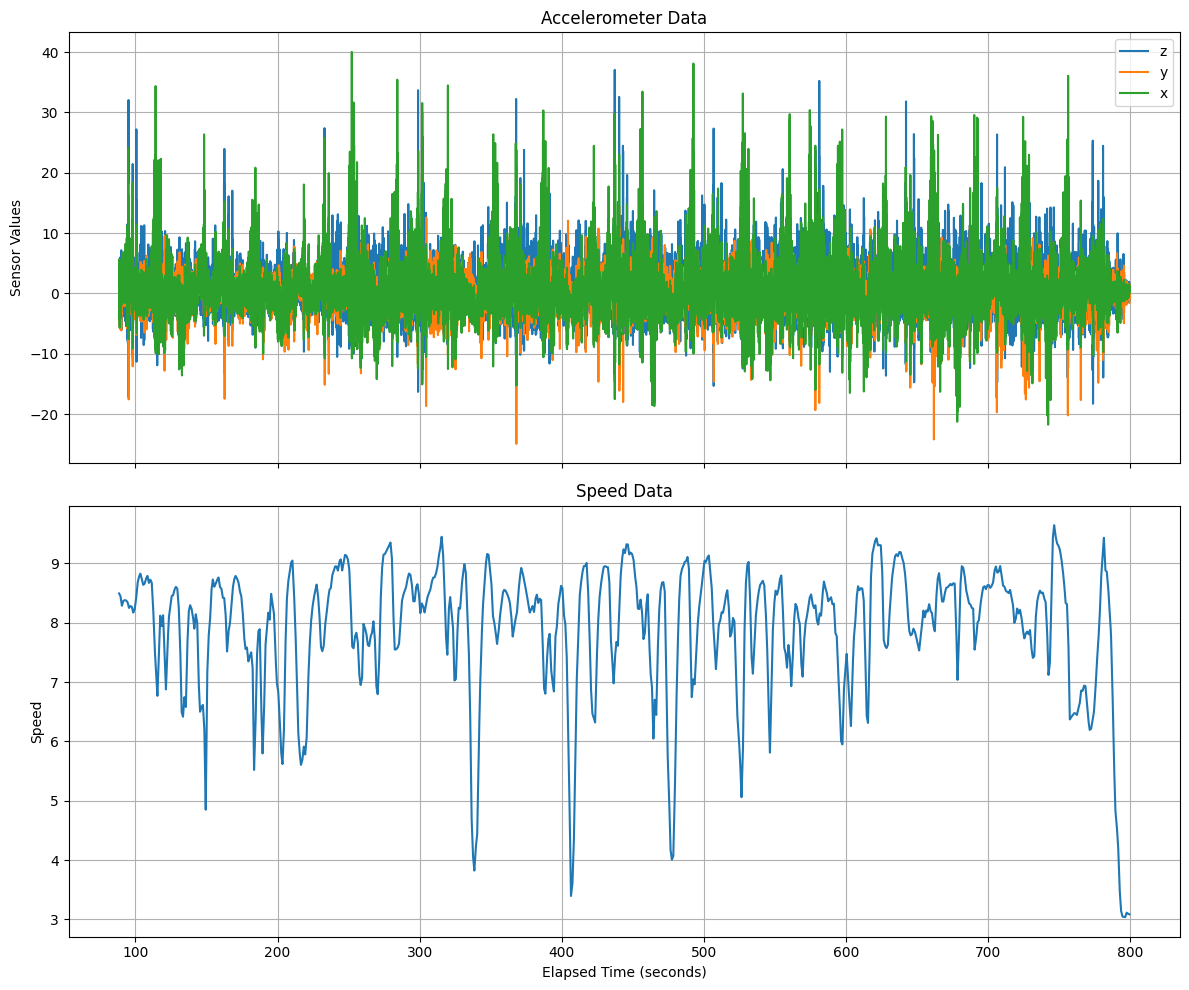

In [8]:
# Visualize data samples
def plot_sensor_with_location(sensor_name):
    df = merged_dfs[sensor_name]
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot sensor data (using first 3 columns after time and timestamp)
    sensor_cols = df.columns[2:5]  # Adjust based on your sensor data structure
    for col in sensor_cols:
        axes[0].plot(df['seconds_elapsed'], df[col], label=col)
    axes[0].set_title(f'{sensor_name.capitalize()} Data')
    axes[0].set_ylabel('Sensor Values')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot location data
    axes[1].plot(df['seconds_elapsed'], df['speed'], label='Speed')
    axes[1].set_title('Speed Data')
    axes[1].set_xlabel('Elapsed Time (seconds)')
    axes[1].set_ylabel('Speed')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot accelerometer data with location
plot_sensor_with_location('accelerometer')

In [10]:
# Save all processed dataframes to CSV or other format
def save_all_data(dfs, format='csv'):
    for name, df in dfs.items():
        if format == 'csv':
            filename = f"{name}_processed.csv"
            df.to_csv(filename, index=False)
            print(f"Saved {filename}")
        elif format == 'parquet':
            filename = f"{name}_processed.parquet"
            df.to_parquet(filename, index=False)
            print(f"Saved {filename}")
    
    print("All files saved successfully")

# Uncomment to save all data
save_all_data(merged_dfs, format='csv')

# Close database connection
conn.close()

print("Processing complete!")

Saved orientation_processed.csv
Saved compass_processed.csv
Saved accelerometer_processed.csv
Saved gravity_processed.csv
Saved gyroscope_processed.csv
Saved magnetometer_processed.csv
Saved wristmotion_processed.csv
All files saved successfully
Processing complete!


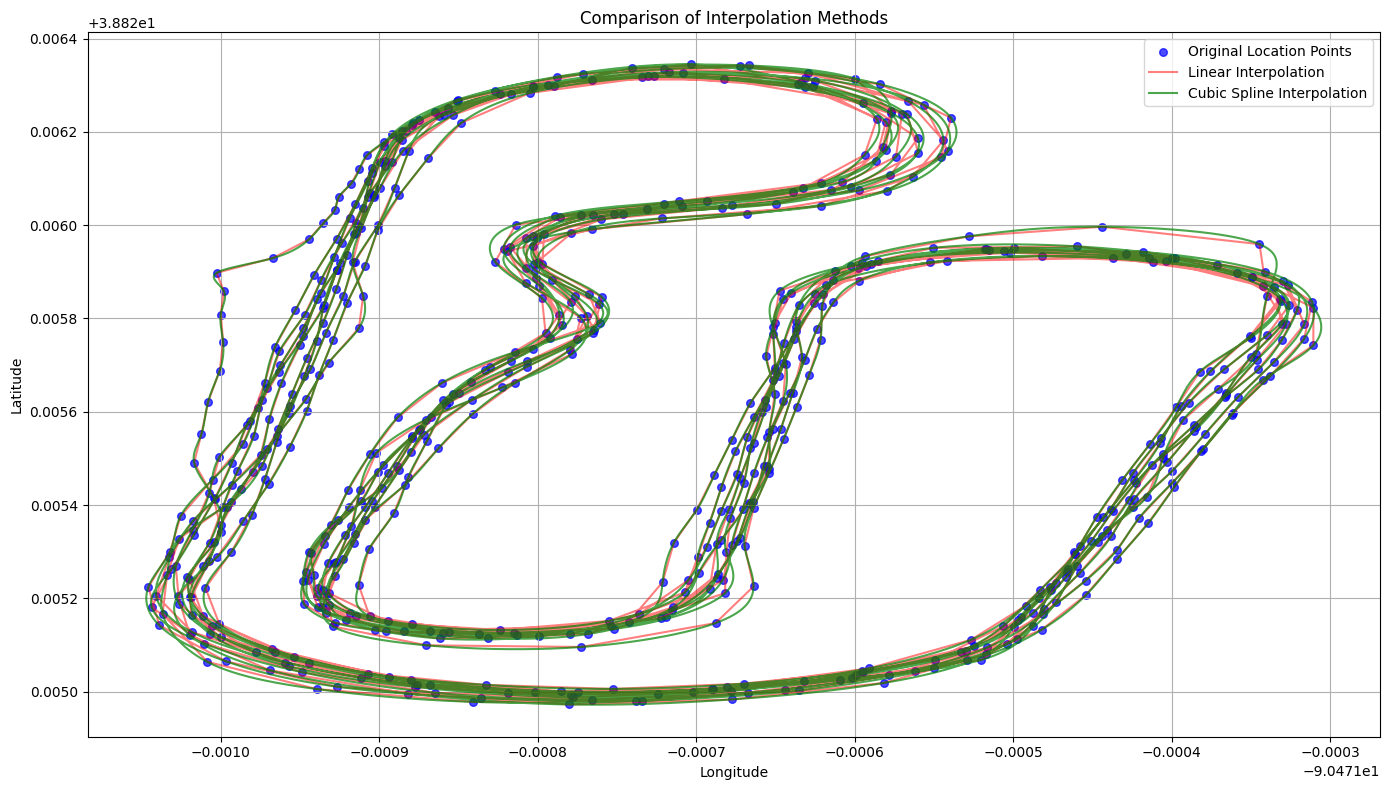

In [11]:
# Improved interpolation method using scipy's more advanced interpolation

import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz
from scipy import interpolate

# Connect to the SQLite database
conn = sqlite3.connect('b.sqlite')

# Function to convert nanosecond timestamps to human readable format
def convert_timestamp(timestamp):
    # Convert nanoseconds to milliseconds (10^6)
    milliseconds = timestamp / 1000000
    # Convert to datetime object
    dt = datetime.fromtimestamp(milliseconds/1000, tz=pytz.UTC)
    return dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]  # Format with milliseconds

# Load location data
location_df = pd.read_sql_query("SELECT * FROM location", conn)
location_df['timestamp'] = location_df['time'].apply(convert_timestamp)

# Load one sensor table to test improved interpolation
accelerometer_df = pd.read_sql_query("SELECT * FROM accelerometer", conn)
accelerometer_df['timestamp'] = accelerometer_df['time'].apply(convert_timestamp)

# Improved interpolation function using cubic spline
def interpolate_location_data_improved(sensor_df, location_df):
    # Ensure dataframes are sorted by time
    sensor_df = sensor_df.sort_values('time')
    location_df = location_df.sort_values('time')
    
    # Create a new dataframe with all sensor timestamps
    merged_df = sensor_df.copy()
    
    # Location columns to interpolate
    loc_columns = ['latitude', 'longitude', 'altitude', 'speed', 'bearing', 
                  'horizontalAccuracy', 'verticalAccuracy', 'speedAccuracy', 
                  'bearingAccuracy', 'altitudeAboveMeanSeaLevel', 'seconds_elapsed']
    
    # Create more sophisticated interpolation for each location column
    for col in loc_columns:
        # Filter out any NaN values in the source data
        valid_loc = location_df[['time', col]].dropna()
        
        if len(valid_loc) > 3:  # Need at least 4 points for cubic spline
            # Create cubic spline interpolation function
            interp_func = interpolate.interp1d(
                valid_loc['time'], 
                valid_loc[col],
                kind='cubic',  # Use cubic spline for smoother transitions
                bounds_error=False,  # Don't raise error for out of bounds
                fill_value=np.nan  # Fill with NaN outside bounds
            )
            merged_df[col] = interp_func(merged_df['time'])
        else:
            # Fallback to linear if not enough points
            interp_func = interpolate.interp1d(
                valid_loc['time'], 
                valid_loc[col],
                kind='linear',
                bounds_error=False,
                fill_value=np.nan
            )
            merged_df[col] = interp_func(merged_df['time'])
    
    return merged_df

# Compare the original and improved interpolation
accel_with_location_linear = interpolate_location_data(accelerometer_df, location_df)
accel_with_location_cubic = interpolate_location_data_improved(accelerometer_df, location_df)

# Visualization to compare interpolation methods
plt.figure(figsize=(14, 8))

# Plot original location data
plt.scatter(location_df['longitude'], location_df['latitude'], 
           c='blue', s=30, alpha=0.7, label='Original Location Points')

# Plot linear interpolation
plt.plot(accel_with_location_linear['longitude'], accel_with_location_linear['latitude'], 
        'r-', alpha=0.5, label='Linear Interpolation')

# Plot cubic spline interpolation
plt.plot(accel_with_location_cubic['longitude'], accel_with_location_cubic['latitude'], 
        'g-', alpha=0.7, label='Cubic Spline Interpolation')

plt.title('Comparison of Interpolation Methods')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_28287/437839666.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = temp_series.interpolate(method='nearest').fillna(method='bfill').fillna(method='ffill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_28287/437839666.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = temp_series.interpolate(method='nearest').fillna(method='bfill').fillna(method='ffill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_28287/437839666.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = temp_series.interpolate(method='nearest').fillna(method='bfill').fillna(method='ffill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf08000

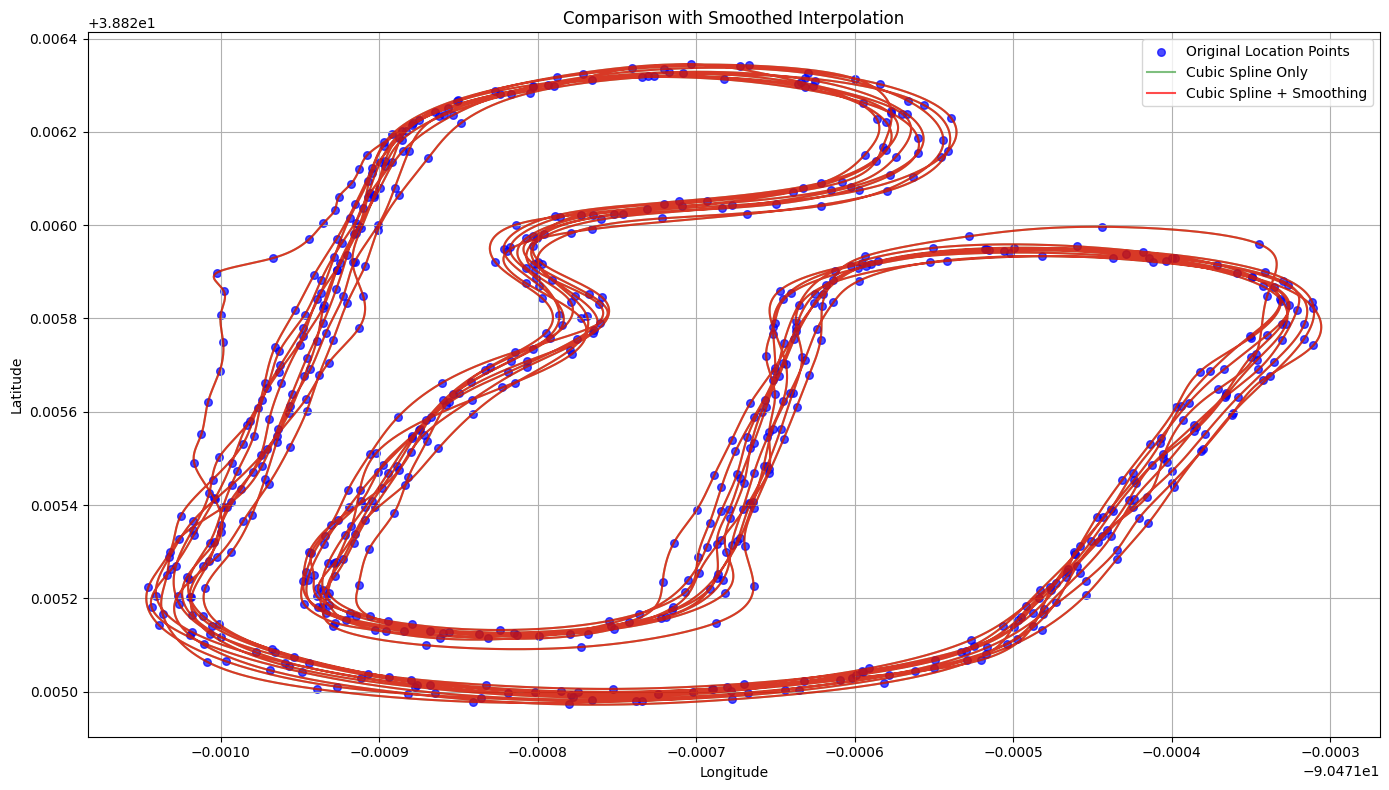

In [12]:
from scipy.signal import savgol_filter

# Advanced interpolation with smoothing
def interpolate_and_smooth_location(sensor_df, location_df, window_length=11, poly_order=3):
    # Get the basic interpolation first
    merged_df = interpolate_location_data_improved(sensor_df, location_df)
    
    # Location columns to smooth
    loc_columns = ['latitude', 'longitude', 'altitude', 'speed', 'bearing']
    
    # Apply Savitzky-Golay filter for smoothing the interpolated data
    for col in loc_columns:
        # Need enough data points for the window length
        if len(merged_df) > window_length:
            # Handle NaN values by replacing with nearby valid values temporarily
            temp_series = merged_df[col].copy()
            mask = temp_series.isna()
            
            if mask.all():
                continue  # Skip if all values are NaN
                
            temp_series = temp_series.interpolate(method='nearest').fillna(method='bfill').fillna(method='ffill')
            
            # Apply the filter
            smoothed = savgol_filter(temp_series, window_length, poly_order)
            
            # Put back NaN where they were originally
            smoothed_series = pd.Series(smoothed, index=merged_df.index)
            smoothed_series[mask] = np.nan
            
            # Update the column
            merged_df[col] = smoothed_series
    
    return merged_df

# Apply the improved interpolation and smoothing
accel_with_location_smoothed = interpolate_and_smooth_location(
    accelerometer_df, location_df, window_length=51, poly_order=3
)

# Visualize the smoothed interpolation
plt.figure(figsize=(14, 8))

# Plot original location data
plt.scatter(location_df['longitude'], location_df['latitude'], 
           c='blue', s=30, alpha=0.7, label='Original Location Points')

# Plot cubic spline interpolation
plt.plot(accel_with_location_cubic['longitude'], accel_with_location_cubic['latitude'], 
        'g-', alpha=0.5, label='Cubic Spline Only')

# Plot smoothed interpolation
plt.plot(accel_with_location_smoothed['longitude'], accel_with_location_smoothed['latitude'], 
        'r-', alpha=0.7, label='Cubic Spline + Smoothing')

plt.title('Comparison with Smoothed Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Processing orientation...
  Original rows: 70815
  After truncation: 70716
Processing compass...
  Original rows: 70815
  After truncation: 70716
Processing accelerometer...
  Original rows: 70815
  After truncation: 70716
Processing gravity...
  Original rows: 70815
  After truncation: 70716
Processing gyroscope...


/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_28287/437839666.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = temp_series.interpolate(method='nearest').fillna(method='bfill').fillna(method='ffill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_28287/437839666.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = temp_series.interpolate(method='nearest').fillna(method='bfill').fillna(method='ffill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf080000gn/T/ipykernel_28287/437839666.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = temp_series.interpolate(method='nearest').fillna(method='bfill').fillna(method='ffill')
/var/folders/24/y__mx0xd3rn5g48sf3wlvf08000

  Original rows: 70815
  After truncation: 70716
Processing magnetometer...
  Original rows: 70815
  After truncation: 70716
Processing wristmotion...
  Original rows: 71143
  After truncation: 71043


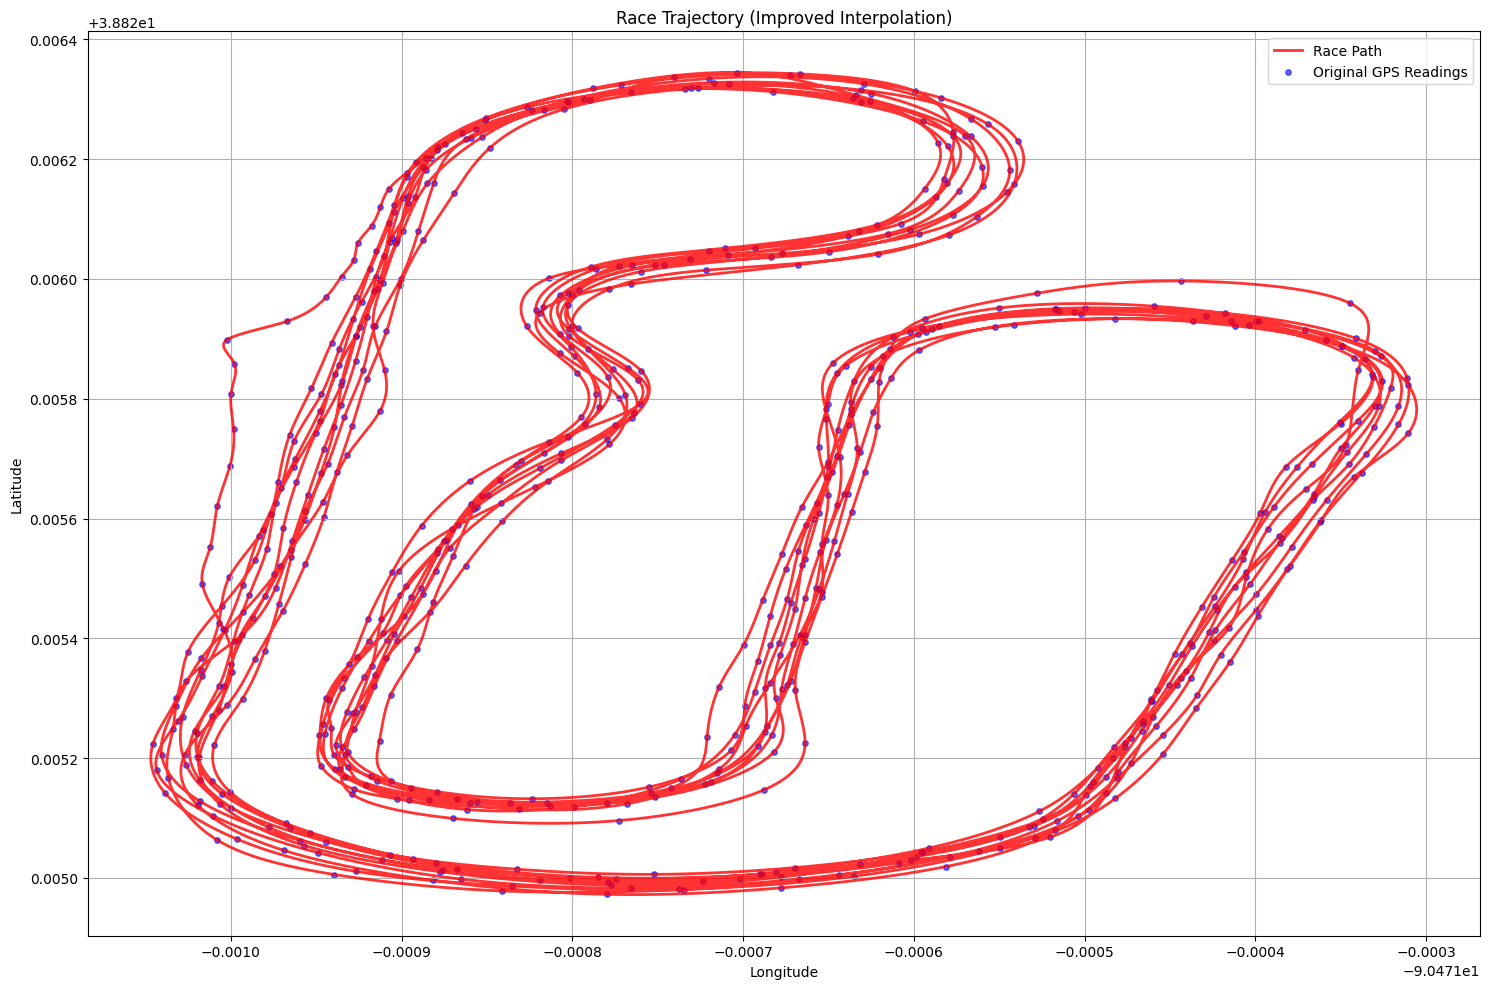

In [13]:
# Load all sensor tables
sensor_tables = ['orientation', 'compass', 'accelerometer', 'gravity', 
                'gyroscope', 'magnetometer', 'wristmotion']

sensor_dfs = {}
for table in sensor_tables:
    sensor_dfs[table] = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    # Add human readable timestamp
    sensor_dfs[table]['timestamp'] = sensor_dfs[table]['time'].apply(convert_timestamp)

# Process all sensor tables with improved interpolation and smoothing
merged_dfs = {}

for table, df in sensor_dfs.items():
    print(f"Processing {table}...")
    # Apply improved interpolation and smoothing
    merged_dfs[table] = interpolate_and_smooth_location(df, location_df)
    
    # Truncate data between 88 and 1046 elapsed seconds
    merged_dfs[table] = merged_dfs[table][
        (merged_dfs[table]['seconds_elapsed'] >= 88) & 
        (merged_dfs[table]['seconds_elapsed'] <= 1046)
    ]
    
    print(f"  Original rows: {len(df)}")
    print(f"  After truncation: {len(merged_dfs[table])}")

# Create a combined visualization of the race trajectory
plt.figure(figsize=(15, 10))

# Plot the smoothed path
plt.plot(merged_dfs['accelerometer']['longitude'], merged_dfs['accelerometer']['latitude'], 
         'r-', linewidth=2, alpha=0.8, label='Race Path')

# Plot original location points
plt.scatter(location_df['longitude'], location_df['latitude'], 
           c='blue', s=15, alpha=0.6, label='Original GPS Readings')

plt.title('Race Trajectory (Improved Interpolation)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Close the database connection
conn.close()

In [14]:
for table_name, df in merged_dfs.items():
    output_filename = f"{table_name}_with_location.csv"
    df.to_csv(output_filename, index=False)
    print(f"Saved {output_filename} with {len(df)} rows")

print("All data saved successfully!")

Saved orientation_with_location.csv with 70716 rows
Saved compass_with_location.csv with 70716 rows
Saved accelerometer_with_location.csv with 70716 rows
Saved gravity_with_location.csv with 70716 rows
Saved gyroscope_with_location.csv with 70716 rows
Saved magnetometer_with_location.csv with 70716 rows
Saved wristmotion_with_location.csv with 71043 rows
All data saved successfully!


In [7]:
import pandas as pd
import numpy as np
from datetime import datetime

# Read the CSV file
df = pd.read_csv('./gateway/one/Location.csv')

# First, let's determine what kind of timestamp this is
# Convert to a readable timestamp
# The value seems too large for a standard Unix timestamp, so let's try a few approaches

# Approach 1: Assuming it's nanoseconds since Unix epoch
def convert_timestamp(ts):
    try:
        # Convert from nanoseconds to seconds
        seconds = ts / 1e9
        # Convert to datetime
        return pd.to_datetime(seconds, unit='s')
    except:
        return pd.NaT

# Apply conversion
df['timestamp'] = df['time'].apply(convert_timestamp)

# If that didn't work (all NaT or strange dates), try another approach
# Use datetime objects for comparison instead of strings
if (df['timestamp'].isna().all() or 
    (df['timestamp'].min() < pd.Timestamp('1900-01-01')) or 
    (df['timestamp'].max() > pd.Timestamp('2100-01-01'))):
    # Try assuming it's nanoseconds since 2001-01-01 (Apple's reference date)
    apple_epoch = pd.Timestamp('2001-01-01')
    df['timestamp'] = df['time'].apply(lambda ts: apple_epoch + pd.Timedelta(seconds=ts/1e9) if pd.notna(ts) else pd.NaT)

# Output a sample of the data to verify
print(df[['time', 'timestamp']].head())

# Save to a new CSV file
df.to_csv('./gateway/one/Location_with_timestamp.csv', index=False)

print(f"Processed {len(df)} rows and saved to ./gateway/one/Location_with_timestamp.csv")

                  time                     timestamp
0  1759444664882683100 2025-10-02 22:37:44.882683039
1  1759444706312882000 2025-10-02 22:38:26.312881947
2  1759444706337237000 2025-10-02 22:38:26.337236881
3  1759444707137066000 2025-10-02 22:38:27.137065887
4  1759444709331727000 2025-10-02 22:38:29.331727028
Processed 983 rows and saved to ./gateway/one/Location_with_timestamp.csv


# Gateway determine start/stop etc by laptimes



In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from datetime import datetime
from geopy.distance import great_circle

# --- Configuration ---
# Filepaths
DATA_FILE = './gateway/one/Location.csv'
OUTPUT_FILE = '/gateway/one/Location_analyzed_trace.csv'

# Lap Times provided by the user (in seconds)
LAP_TIMES_INPUT = """
1,48.240
2,46.015
3,55.148
4,45.784
5,45.522
6,43.504
7,45.544
8,50.858
9,47.876
10,113.049
11,45.481
12,52.743
"""

# Smoothing parameters (Savitzky-Golay Filter)
# window_length: Must be an odd number. Higher value means more smoothing.
WINDOW_LENGTH = 51 
# polyorder: Polynomial order used to fit the samples. Must be less than window_length.
POLY_ORDER = 3 

# Start/Finish Detection Tolerance
# Max distance in meters for a point to be considered a "lap crossing" point.
# A small value (e.g., 5-10 meters) is ideal for defining the line.
SF_DISTANCE_TOLERANCE_M = 10 

def parse_lap_times(lap_times_str):
    """Parses lap times string and calculates cumulative crossing times."""
    
    lap_data = []
    current_cumulative_time = 0.0
    
    for line in lap_times_str.strip().split('\n'):
        try:
            lap_number, time_str = line.split(',')
            lap_time = float(time_str)
            current_cumulative_time += lap_time
            lap_data.append({
                'lap': int(lap_number),
                'lap_time_s': lap_time,
                'crossing_time_s': current_cumulative_time
            })
        except ValueError:
            print(f"Skipping malformed line: {line}")
            
    # The first crossing occurs after the first lap time. We add the start time (0.0) 
    # as the beginning of the first lap.
    crossing_times = [0.0] + [d['crossing_time_s'] for d in lap_data]
    
    return crossing_times, lap_data

def process_data():
    """Main function to load, process, smooth, and analyze the position data."""
    print("Loading data...")
    try:
        # Load the entire DataFrame first to dynamically check columns
        df = pd.read_csv(DATA_FILE)
        df = df.dropna(subset=['seconds_elapsed']).reset_index(drop=True)

        # --- Dynamic Column Selection (Location & Timestamp) ---
        latitude_col = None
        longitude_col = None
        timestamp_col = None

        # 1. Location Column Check
        if 'latitude' in df.columns and 'longitude' in df.columns:
            print("Using primary 'latitude' and 'longitude' columns.")
            latitude_col = 'latitude'
            longitude_col = 'longitude'
        elif 'latitude' in df.columns and 'longitude' in df.columns:
            print("Primary location data missing. Using generic 'latitude' and 'longitude' columns.")
            latitude_col = 'latitude'
            longitude_col = 'longitude'
        else:
            print("Error: Required latitude/longitude columns ('latitude'/'longitude' or 'latitude'/'longitude') not found in the CSV file.")
            print("The script was specifically instructed NOT to use 'watchLocation_' data.")
            print(f"Available columns: {list(df.columns)}")
            return

        # 2. Timestamp Column Check
        if 'timestamp' in df.columns:
            print("Found 'timestamp' column for time slider analysis.")
            timestamp_col = 'timestamp'
        
        # Rename selected location columns to generic names ('latitude', 'longitude')
        # for consistent processing in the rest of the script.
        if latitude_col != 'latitude':
            df = df.rename(columns={latitude_col: 'latitude'})
        if longitude_col != 'longitude':
            df = df.rename(columns={longitude_col: 'longitude'})

        # Filter out rows missing essential data
        required_cols = ['seconds_elapsed', 'latitude', 'longitude']
        if timestamp_col:
            required_cols.append(timestamp_col)
            
        df = df.dropna(subset=required_cols).reset_index(drop=True)

        # --- Convert Timestamp to Kepler Format (ms since epoch) ---
        if timestamp_col:
            print("Converting timestamp (assuming nanoseconds) to milliseconds for Kepler.gl...")
            # Assuming 19-digit number is nanoseconds. Divide by 1e6 to get milliseconds (13 digits).
            try:
                # Use .apply(lambda x: x // 1000000) for robustness with very large numbers
                df['kepler_timestamp'] = (df[timestamp_col] / 1e6).astype(np.int64)
                print("Timestamp conversion successful.")
            except Exception as e:
                print(f"Warning: Could not convert timestamp column '{timestamp_col}' to integer milliseconds. Error: {e}")
                timestamp_col = None # Disable further use if conversion fails


    except Exception as e:
        print(f"Error during data loading or initial column check: {e}")
        return

    # --- 1. Data Cleaning and Smoothing (F1-Style Trace) ---
    print("Applying smoothing to GPS trace...")
    
    # Apply Savitzky-Golay filter for a smooth, high-fidelity trace
    # Only apply if we have enough data points for the chosen window length
    if len(df) >= WINDOW_LENGTH:
        df['latitude_smooth'] = savgol_filter(df['latitude'], WINDOW_LENGTH, POLY_ORDER)
        df['longitude_smooth'] = savgol_filter(df['longitude'], WINDOW_LENGTH, POLY_ORDER)
    else:
        print(f"Warning: Not enough data points ({len(df)}) for requested window length ({WINDOW_LENGTH}). Using raw coordinates.")
        df['latitude_smooth'] = df['latitude']
        df['longitude_smooth'] = df['longitude']

    # --- 2. Start/Finish Line Detection ---
    print("Calculating lap crossing times...")
    crossing_times_s, lap_data = parse_lap_times(LAP_TIMES_INPUT)
    
    if not crossing_times_s:
        print("Error: Could not parse any lap times.")
        return

    print(f"Total laps detected: {len(crossing_times_s) - 1}")

    # Find the data point that corresponds to each lap crossing time
    crossing_indices = []
    
    # The first crossing time (0.0) corresponds to the first data point (lap start)
    crossing_indices.append(df.index[0])
    
    # Find the index closest to each subsequent crossing time
    for target_time in crossing_times_s[1:]:
        # Find the row index where 'seconds_elapsed' is closest to the target_time
        # using idxmin on the absolute difference
        try:
            closest_index = (df['seconds_elapsed'] - target_time).abs().idxmin()
            crossing_indices.append(closest_index)
        except ValueError:
            # Handle case where target_time is outside the data range
            print(f"Warning: Target time {target_time:.3f}s exceeded data length.")
            break
            
    crossing_points_df = df.loc[crossing_indices].copy()
    crossing_points_df['lap_crossing'] = [f'Lap {i} Crossing' for i in range(len(crossing_indices))]
    
    print(f"Found {len(crossing_indices)} lap crossing points.")

    # --- 3. Determine Start/Finish Line Location ---
    # The Start/Finish line is the point on the track where the car passed at the calculated times.
    # Because of GPS jitter, we average the smooth coordinates of all crossing points.
    
    sf_lat = crossing_points_df['latitude_smooth'].mean()
    sf_lon = crossing_points_df['longitude_smooth'].mean()
    
    # --- 4. Refine S/F Line Search (Optional but Robust) ---
    # We look for a geographical segment that is repeatedly crossed in the expected lap time.
    # The "line" is defined by the average position of the start and end of the segment.
    
    # Create a column to store the distance from the estimated S/F point (in meters)
    # Using the Great Circle formula for real-world distance
    sf_point = (sf_lat, sf_lon)
    df['dist_to_sf_m'] = df.apply(
        lambda row: great_circle((row['latitude_smooth'], row['longitude_smooth']), sf_point).meters,
        axis=1
    )
    
    # Identify the S/F zone where the distance is within tolerance
    df['in_sf_zone'] = df['dist_to_sf_m'] < SF_DISTANCE_TOLERANCE_M
    
    sf_zone_entries = df[df['in_sf_zone']].index.tolist()
    
    # A simple check: if the first and last point are in the SF zone, 
    # and the lap crossings are in the SF zone, the estimation is valid.

    print("\n--- Start/Finish Line Results ---")
    print(f"Estimated S/F Location (Lat, Lon): ({sf_lat:.6f}, {sf_lon:.6f})")
    print(f"Estimated S/F Zone Size: {SF_DISTANCE_TOLERANCE_M} meters radius.")
    
    # --- 5. Output Results ---
    
    # Create the final output DataFrame containing the smoothed trace and S/F flag
    df_output = df.copy()
    
    # Add a marker column for the crossing points
    df_output['is_lap_crossing'] = df_output.index.isin(crossing_indices)
    df_output['lap_number'] = ''
    
    for i, idx in enumerate(crossing_indices):
        if i > 0:
            df_output.loc[idx, 'lap_number'] = f'Lap {i} End'
        else:
            df_output.loc[idx, 'lap_number'] = 'Race Start'

    # Select and reorder columns for output
    final_cols = [
        'seconds_elapsed', 
        'latitude', 
        'longitude', 
        'latitude_smooth', 
        'longitude_smooth', 
        'dist_to_sf_m',
        'in_sf_zone',
        'is_lap_crossing',
        'lap_number'
    ]

    # Add Kepler timestamp if available and successfully converted
    if timestamp_col:
        final_cols.insert(1, 'kepler_timestamp') 
    
    df_output = df_output[final_cols]
    
    df_output.to_csv(OUTPUT_FILE, index=False)
    
    print(f"\nAnalysis complete. Smoothed trace and S/F data saved to: {OUTPUT_FILE}")

    # Optionally display the identified crossing points
    print("\nLap Crossing Points (Smoothed Coordinates):")
    print(crossing_points_df[['lap_crossing', 'seconds_elapsed', 'latitude_smooth', 'longitude_smooth']])


if __name__ == '__main__':
    # Ensure geopy is installed for robust distance calculation
    try:
        from geopy.distance import great_circle
    except ImportError:
        print("Error: The 'geopy' library is required for accurate distance calculation. Please install it using: pip install geopy")
        exit()
        
    process_data()


Loading data...
Applying smoothing to GPS trace...
Calculating lap crossing times...
Total laps detected: 12
Found 13 lap crossing points.

--- Start/Finish Line Results ---
Estimated S/F Location (Lat, Lon): (38.648664, -90.135137)
Estimated S/F Zone Size: 10 meters radius.

Analysis complete. Smoothed trace and S/F data saved to: ./gateway/one/Location_analyzed_trace.csv

Lap Crossing Points (Smoothed Coordinates):
        lap_crossing  seconds_elapsed  latitude_smooth  longitude_smooth
0     Lap 0 Crossing         0.252882        38.648649        -90.135314
47    Lap 1 Crossing        47.940228        38.648720        -90.135512
93    Lap 2 Crossing        93.939210        38.648716        -90.135510
148   Lap 3 Crossing       148.939852        38.648727        -90.135502
194   Lap 4 Crossing       194.939408        38.648732        -90.135498
240   Lap 5 Crossing       240.938892        38.648548        -90.134933
283   Lap 6 Crossing       283.939703        38.648340        -90.13